In [166]:
import pandas as pd
import os
from io import StringIO
from pandas import json_normalize
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import hmean

In [167]:
architecture = "GCN"
folder = os.path.join("output","runs","LinkAttack")

files = [f for f in os.listdir(folder) if architecture in f]
files

['AmazonComputers_GCN_99forget_edge.json',
 'Pubmed_GCN_edge.json',
 'AmazonComputers_GCN_50forget_edge.json',
 'AmazonComputers_GCN_edge.json',
 'Pubmed_GCN_99forget_edge.json',
 'Citeseer_GCN_99forget_edge.json',
 'Cora_GCN_edge.json',
 'Citeseer_GCN_50forget_edge.json',
 'Citeseer_GCN_edge.json',
 'Cora_GCN_50forget_edge.json',
 'Cora_GCN_99forget_edge.json']

In [168]:
column_list = ['unlearner', 'dataset', 'architecture', 'percentage', 'optimizer.parameters.lr','lr',
       'RunTime', 'PeakRSS_MB', 'CudaPeak_MB', 'AUS', 'UMIA',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:True', 'sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.train.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:False',
       'sklearn.metrics.accuracy_score.test.original.on_graph:False',
       'f1_macro.test.unlearned.on_graph:True',
       'f1_macro.test.original.on_graph:True',
       'f1_macro.forget.unlearned.on_graph:True',
       'f1_macro.forget.original.on_graph:True',
       'Link Stealing Attack unlearned 0 exist/non_exist',
       'Link Stealing Attack 0 unlearned forget/non_exist', 'LinkTeller unlearn with sampler bfs+:',
       'LinkTeller original with sampler bfs+:']


In [169]:
total_df = pd.DataFrame()

for file in files:
    architecture = file.split("_")[1]
    if architecture == "SGC" and "CGU" in file:
        architecture = "SGC_CGU"
    
    if '50' in file:
        percentage = 50
    elif '99' in file:
        percentage = 99
    else:
        percentage = 20
        
    file = os.path.join(folder,file)
    with open(file, "r") as f:
        text = f.read().strip()

    if not text.startswith("["):
        text = "[" + text
    if text.endswith(","):
        text = text[:-1]
    if not text.endswith("]"):
        text = text + "]"

    df = pd.read_json(StringIO(text))

    df_expanded = json_normalize(df['parameters'])
    df = pd.concat([df.drop(columns='parameters'), df_expanded], axis=1)

    df['architecture'] = architecture
    df['percentage'] = percentage

    cols = list(df.columns)

    #cols.insert(2, cols.pop(cols.index('optimizer.parameters.lr')))

    cols.insert(2, cols.pop(cols.index('architecture')))

    df = df[cols]
    
    total_df = pd.concat([total_df,df])

In [170]:
total_df = total_df[column_list]

In [171]:
linkteller_unlearn = total_df["LinkTeller unlearn with sampler bfs+:"].apply(pd.Series)
linkteller_unlearn = linkteller_unlearn.rename(columns=lambda x: f"LinkTeller_unlearn_{x}")

linkteller_original = total_df["LinkTeller original with sampler bfs+:"].apply(pd.Series)
linkteller_original = linkteller_original.rename(columns=lambda x: f"LinkTeller_original_{x}")

total_df = pd.concat([total_df.drop(columns=[
    "LinkTeller unlearn with sampler bfs+:",
    "LinkTeller original with sampler bfs+:"
]), linkteller_unlearn, linkteller_original], axis=1)

In [172]:
total_df['percentage']

0     99
1     99
2     99
3     99
4     99
      ..
12    99
13    99
14    99
15    99
16    99
Name: percentage, Length: 204, dtype: int64

In [173]:
column_list = ['unlearner', 'dataset', 'architecture', 'percentage', 'optimizer.parameters.lr','lr',
       'RunTime', 'AUS', 'UMIA',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:True', 'sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.train.unlearned.on_graph:True',
       'sklearn.metrics.accuracy_score.test.unlearned.on_graph:False',
       'sklearn.metrics.accuracy_score.test.original.on_graph:False',
       'Link Stealing Attack unlearned 0 exist/non_exist',
       'Link Stealing Attack 0 unlearned forget/non_exist', 'LinkTeller_unlearn_auc',
       'LinkTeller_unlearn_ap', 'LinkTeller_original_auc', 'LinkTeller_original_ap']

total_df = total_df[column_list]
total_df.reset_index(drop=True, inplace=True)

In [174]:
metric_cols = [c for c in column_list if c not in ["unlearner","dataset","architecture","lr","RunTime", 'optimizer.parameters.lr',  'Link Stealing Attack unlearned 0 exist/non_exist',
 'Link Stealing Attack 0 unlearned forget/non_exist',
 'LinkTeller_unlearn_auc',
 'LinkTeller_unlearn_ap',
 'LinkTeller_original_auc',
 'LinkTeller_original_ap']]

In [175]:
total_df

,unlearner,dataset,architecture,percentage,optimizer.parameters.lr,lr,RunTime,AUS,UMIA,sklearn.metrics.accuracy_score.test.unlearned.on_graph:True,sklearn.metrics.accuracy_score.forget.unlearned.on_graph:True,sklearn.metrics.accuracy_score.train.unlearned.on_graph:True,sklearn.metrics.accuracy_score.test.unlearned.on_graph:False,sklearn.metrics.accuracy_score.test.original.on_graph:False,Link Stealing Attack unlearned 0 exist/non_exist,Link Stealing Attack 0 unlearned forget/non_exist,LinkTeller_unlearn_auc,LinkTeller_unlearn_ap,LinkTeller_original_auc,LinkTeller_original_ap
0,Identity,Computers,GCN,99,NaN,NaN,0.000231,0.991736,0.499318,0.459833,0.464182,0.466519,0.511450,0.51145,0.727672,0.727133,0.506377,0.652213,0.506310,0.652166
1,GoldModelGraph,Computers,GCN,99,NaN,NaN,0.218163,0.903577,0.667347,0.405671,0.416599,0.418948,0.405671,0.51145,0.521951,0.521420,0.503608,0.650261,0.506347,0.652191
2,Finetuning,Computers,GCN,99,0.001,NaN,5.836596,1.086086,0.498046,0.488550,0.497884,0.498738,0.619048,0.51145,0.779422,0.779063,0.505985,0.651936,0.506278,0.652142
3,SuccessiveRandomLabels,Computers,GCN,99,0.001,NaN,601.858520,0.980656,0.502590,0.450382,0.457353,0.458843,0.503090,0.51145,0.666977,0.666355,0.506144,0.652048,0.506368,0.652207
4,Finetuning,Computers,GCN,99,0.001,NaN,4.984550,1.077474,0.496274,0.483824,0.491871,0.492375,0.608506,0.51145,0.776484,0.776175,0.506233,0.652110,0.506248,0.652121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,SelectiveSynapticDampening,Cora,GCN,99,0.001,0.1,21.576113,0.966159,0.510829,0.507380,0.496677,0.500513,0.516605,0.53690,0.739529,0.733388,0.500427,0.853971,0.500427,0.853971
200,Cascade,Cora,GCN,99,NaN,NaN,29.855157,1.064061,0.489862,0.544280,0.532496,0.532308,0.629151,0.53690,0.779622,0.773589,0.500427,0.853971,0.500427,0.853971
201,IDEA,Cora,GCN,99,NaN,NaN,0.851932,0.905573,0.800000,0.472325,0.474151,0.482564,0.472325,0.53690,0.718278,0.713043,0.500427,0.853971,0.500427,0.853971
202,CGU_edge,Cora,GCN,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.53690,NaN,NaN,NaN,NaN,0.500427,0.853971


In [176]:
df_to_plot = total_df[['unlearner','dataset','percentage','UMIA','sklearn.metrics.accuracy_score.test.unlearned.on_graph:True']]
df_to_plot['percentage'] = pd.Categorical(df_to_plot['percentage'], categories=[20, 50, 99], ordered=True)
df_to_plot

/tmp/ipykernel_3117227/3954790102.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_plot['percentage'] = pd.Categorical(df_to_plot['percentage'], categories=[20, 50, 99], ordered=True)


,unlearner,dataset,percentage,UMIA,sklearn.metrics.accuracy_score.test.unlearned.on_graph:True
0,Identity,Computers,99,0.499318,0.459833
1,GoldModelGraph,Computers,99,0.667347,0.405671
2,Finetuning,Computers,99,0.498046,0.488550
3,SuccessiveRandomLabels,Computers,99,0.502590,0.450382
4,Finetuning,Computers,99,0.496274,0.483824
...,...,...,...,...,...
199,SelectiveSynapticDampening,Cora,99,0.510829,0.507380
200,Cascade,Cora,99,0.489862,0.544280
201,IDEA,Cora,99,0.800000,0.472325
202,CGU_edge,Cora,99,NaN,NaN


In [177]:
df_to_plot.loc[df_to_plot.unlearner=='GoldModelGraph']

,unlearner,dataset,percentage,UMIA,sklearn.metrics.accuracy_score.test.unlearned.on_graph:True
1,GoldModelGraph,Computers,99,0.667347,0.405671
18,GoldModelGraph,Pubmed,20,0.497195,0.613083
35,GoldModelGraph,Computers,50,0.507088,0.500545
52,GoldModelGraph,Computers,20,0.501545,0.479826
69,GoldModelGraph,Pubmed,99,0.455769,0.576572
86,GoldModelGraph,Citeseer,99,0.695726,0.620120
103,GoldModelGraph,Cora,20,0.499309,0.389299
120,GoldModelGraph,Citeseer,50,0.559287,0.713213
137,GoldModelGraph,Pubmed,50,0.524101,0.603955
154,GoldModelGraph,Citeseer,20,0.535460,0.725225


/tmp/ipykernel_3117227/2737365990.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_plot["percentage"] = df_to_plot["percentage"].astype(pct_dtype)
/tmp/ipykernel_3117227/2737365990.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_to_plot


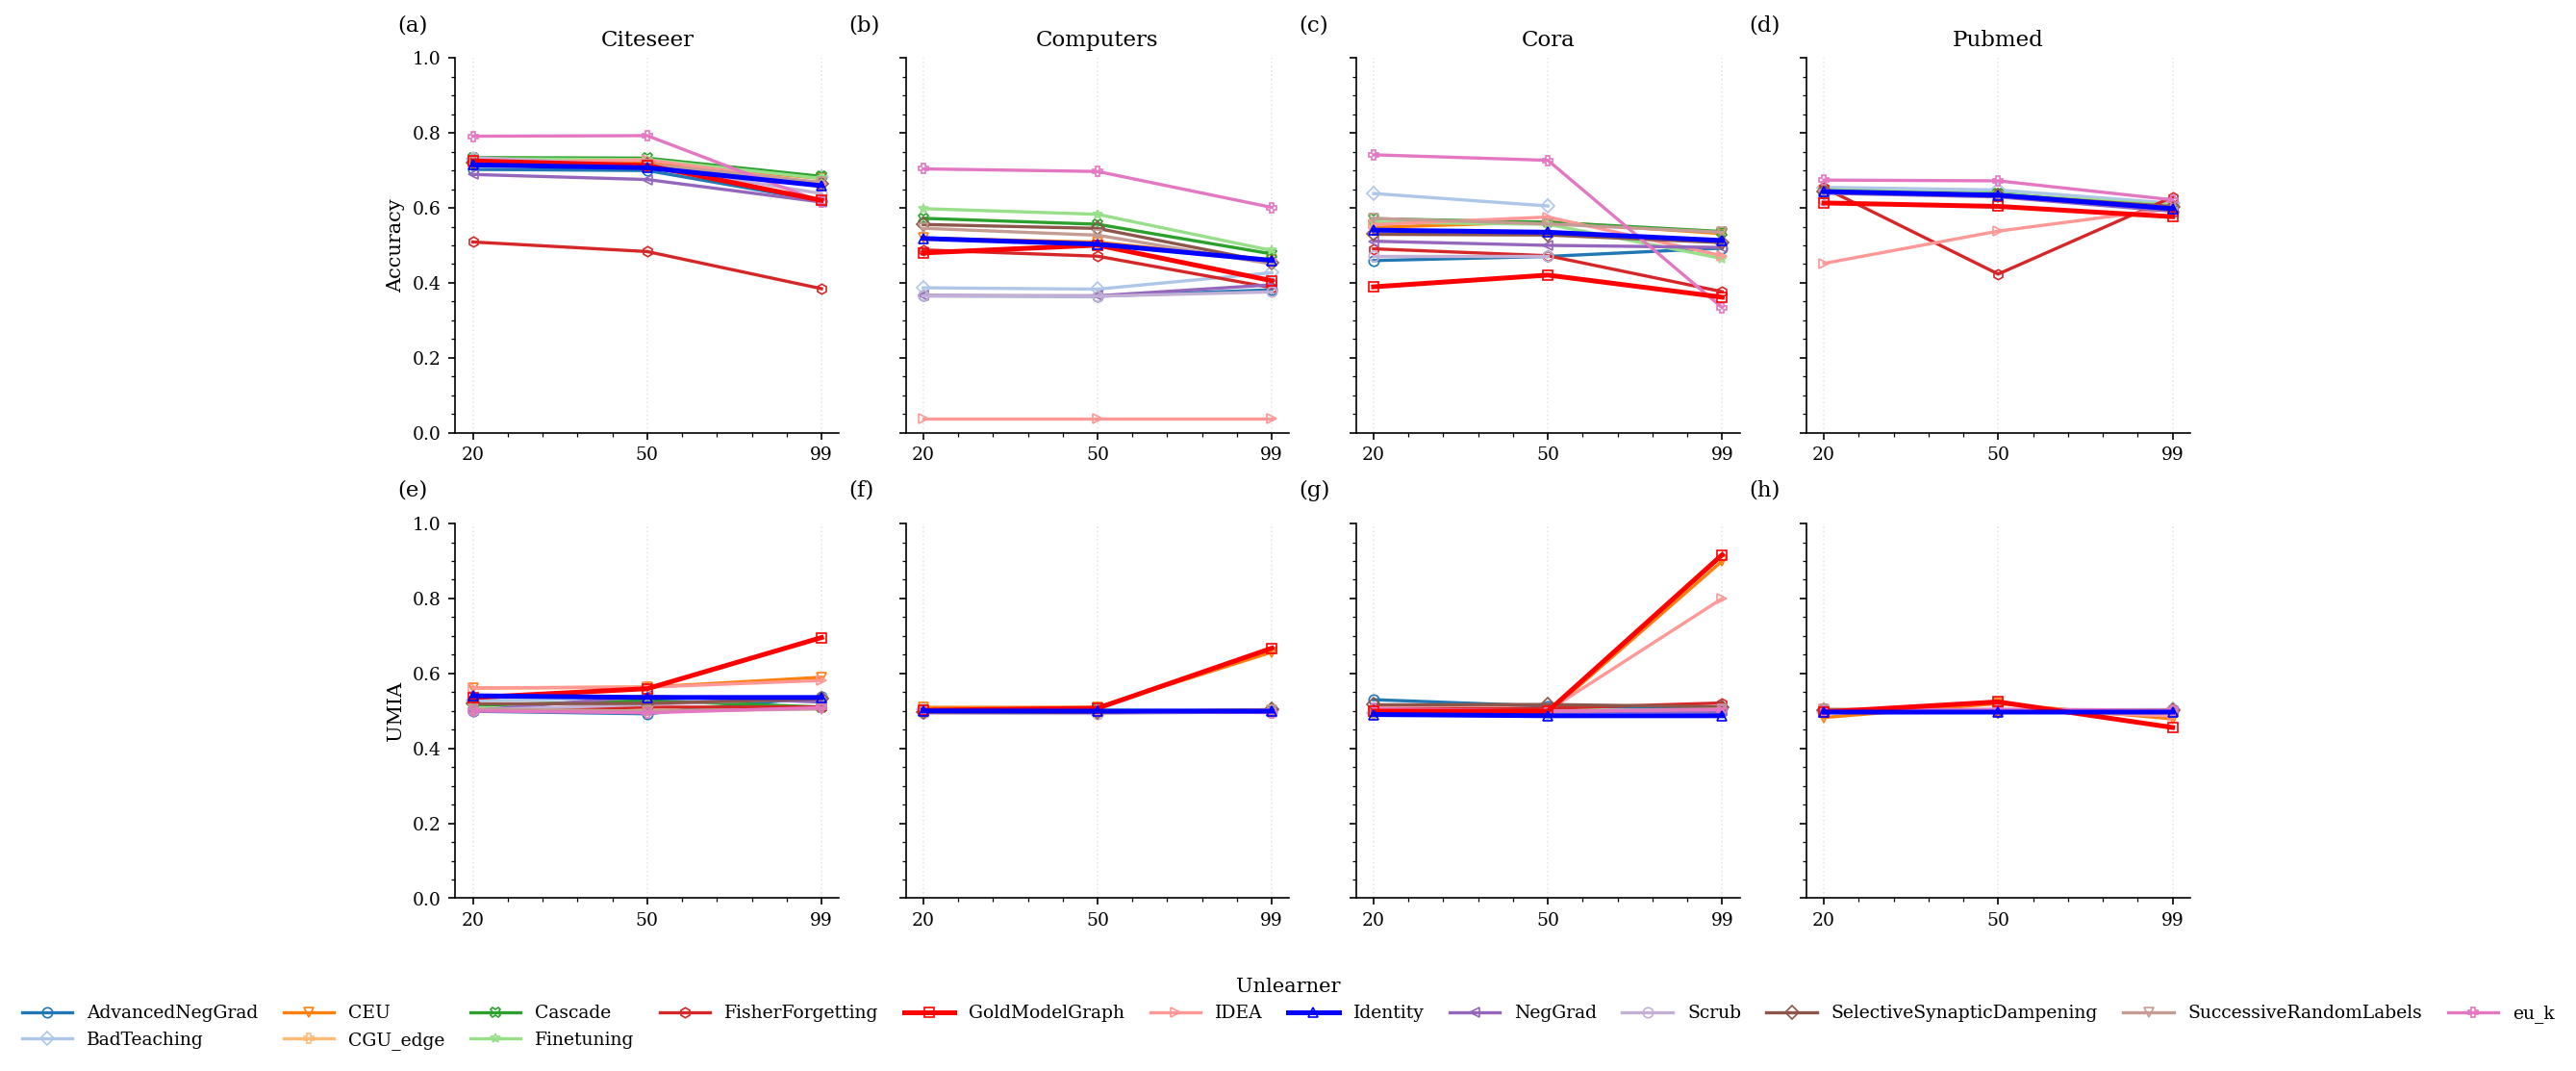

In [178]:
import pandas as pd
import matplotlib.pyplot as plt
from string import ascii_lowercase

# ---------- Global style (paper-ish) ----------
plt.rcParams.update({
    "font.family": "serif",           # looks academic
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "figure.dpi": 150,                # on-screen
    "savefig.dpi": 300,               # export
})

ACC = "sklearn.metrics.accuracy_score.test.unlearned.on_graph:True"
UMIA = "UMIA"

# Ensure ordered categorical for percentages
pct_dtype = pd.api.types.CategoricalDtype(categories=[20, 50, 99], ordered=True)
df_to_plot["percentage"] = df_to_plot["percentage"].astype(pct_dtype)

# Aggregate duplicates (mean) for BOTH metrics
agg = (
    df_to_plot
    .groupby(["dataset", "unlearner", "percentage"], as_index=False)[[ACC, UMIA]]
    .mean()
)

datasets = agg["dataset"].unique()

# 2 rows: row 0 = Accuracy, row 1 = UMIA
fig, axes = plt.subplots(
    2, len(datasets),
    figsize=(3.2*len(datasets), 6.6),
    sharey=True, squeeze=False
)

# ----- Color/marker palette (same as before) -----
all_unlearners = agg["unlearner"].unique().tolist()
highlight_names = ["GoldModelGraph", "Identity"]

base_cmap = plt.get_cmap("tab20")
others = [u for u in all_unlearners if u not in highlight_names]
other_colors = {u: base_cmap(i % base_cmap.N) for i, u in enumerate(others)}

color_map = {**other_colors, "GoldModelGraph": "red", "Identity": "blue"}

marker_map = {"GoldModelGraph": "s", "Identity": "^"}
default_markers = ["o", "D", "v", "P", "X", "*", "h", ">", "<"]
for i, u in enumerate(others):
    marker_map.setdefault(u, default_markers[i % len(default_markers)])

style_map = {
    "GoldModelGraph": {"linewidth": 2.4, "zorder": 5},
    "Identity": {"linewidth": 2.4, "zorder": 5},
}

def plot_row(ax_row, metric, ylabel=None, panel_offset=0):
    """Plot one metric across all dataset columns on the given axes row."""
    handles, labels = [], []
    for j, dataset in enumerate(datasets):
        ax = ax_row[j]
        sdf = agg[agg["dataset"] == dataset]

        for unlearner, udf in sdf.groupby("unlearner"):
            udf = udf.sort_values("percentage", key=lambda s: s.cat.codes)
            x = udf["percentage"].cat.codes
            kwargs = {
                "color": color_map[unlearner],
                "linewidth": 1.6,
                "marker": marker_map[unlearner],
                "markersize": 5,
                "markeredgewidth": 0.8,
                "markerfacecolor": "none",
                "zorder": 2,
            }
            kwargs.update(style_map.get(unlearner, {}))

            (line,) = ax.plot(x, udf[metric], label=unlearner, **kwargs)
            if unlearner not in labels:
                handles.append(line); labels.append(unlearner)

        # Cosmetics (titles only on top row; x labels/ticks on both)
        if ax is axes[0, j]:
            ax.set_title(dataset)
        if ylabel and j == 0:
            ax.set_ylabel(ylabel)

        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels([20, 50, 99])
        ax.set_ylim(0, 1)
        ax.minorticks_on()
        ax.grid(axis="x", linestyle=":", alpha=0.3)

        # Panel labels (a), (b), (c), ... continuing across rows
        label_idx = panel_offset + j
        ax.text(-0.15, 1.06, f"({ascii_lowercase[label_idx]})",
                transform=ax.transAxes, va="bottom", ha="left", fontsize=11)
    return handles, labels

# Top row: Accuracy (identical look)
top_handles, top_labels = plot_row(axes[0], ACC, ylabel="Accuracy", panel_offset=0)

# Bottom row: UMIA
_ , _ = plot_row(axes[1], UMIA, ylabel="UMIA", panel_offset=len(datasets))

# ----- Single legend below; wide & low -----
ncols = min(len(top_labels), 12)
fig.legend(
    top_handles, top_labels,
    loc="lower center",
    ncol=ncols,
    bbox_to_anchor=(0.5, -0.12),
    frameon=False,
    title="Unlearner",
    fontsize=9,
    handlelength=2.8,
    columnspacing=1.4,
    markerscale=1.0,
)

# Space for legend + neat layout
plt.subplots_adjust(bottom=0.20, wspace=0.25, hspace=0.35)
plt.tight_layout()

# Save (vector-friendly)
fig.savefig(os.path.join("figures", "unlearning_accuracy_and_umia.pdf"), bbox_inches="tight", transparent=True)
plt.show()
